# Logistics Network Graph Construction

This notebook builds a directed logistics network using
corridor-level shipment data.

The graph will later be used for:
- bottleneck analysis
- hub importance analysis
- graph-based ETA optimization
- network intelligence

In [1]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

## Load Processed Corridor Dataset

Loading the aggregated corridor-level dataset created during
the exploratory data analysis phase.

In [2]:
corridors = pd.read_csv(
    "../data/processed/corridor_stats.csv"
)

In [3]:
corridors.head()

,source_center,destination_center,avg_actual_time,avg_osrm_time,trip_count,delay_ratio
0,IND000000AAL,IND411033AAA,63.702703,22.216216,37,2.867397
1,IND000000AAS,IND783370AAC,50.555556,25.888889,18,1.952790
2,IND000000ABA,IND683565AAA,30.846154,19.307692,13,1.597610
3,IND000000ABD,IND562132AAA,336.868056,201.986111,144,1.667778
4,IND000000ABG,IND501359AAF,111.170732,20.707317,41,5.368669


In [4]:
corridors.shape

(2203, 6)

In [5]:
corridors.columns

Index(['source_center', 'destination_center', 'avg_actual_time',
       'avg_osrm_time', 'trip_count', 'delay_ratio'],
      dtype='str')

## Build Directed Logistics Graph

Creating a directed graph where:
- nodes represent logistics hubs
- edges represent shipment corridors
- edge weights represent delay severity

In [6]:
G = nx.DiGraph()

In [7]:
for _, row in corridors.iterrows():

    G.add_edge(
        row["source_center"],
        row["destination_center"],
        weight=row["delay_ratio"],
        trips=row["trip_count"]
    )

## Basic Graph Statistics

Inspecting the overall size and connectivity
of the logistics network.

In [8]:
print("Number of Nodes:", G.number_of_nodes())

print("Number of Edges:", G.number_of_edges())

Number of Nodes: 1483
Number of Edges: 2203


## Degree Centrality Analysis

Degree centrality identifies highly connected hubs
within the logistics network.

In [9]:
degree_centrality = nx.degree_centrality(G)

In [10]:
centrality_df = pd.DataFrame({
    "hub": degree_centrality.keys(),
    "degree_centrality": degree_centrality.values()
})

In [11]:
top_hubs = centrality_df.sort_values(
    by="degree_centrality",
    ascending=False
).head(10)

top_hubs

,hub,degree_centrality
20,IND000000ACB,0.062078
7,IND562132AAA,0.047908
58,IND501359AAE,0.037787
19,IND160002AAC,0.037112
55,IND421302AAG,0.036437
88,IND110037AAM,0.028340
1,IND411033AAA,0.028340
61,IND712311AAA,0.027665
42,IND131028AAB,0.024291
60,IND600056AAB,0.022942


### Observations

- A few hubs dominate the logistics network connectivity.
- Highly connected nodes may act as operational relay centers.
- Degree centrality highlights major traffic concentration points.

## Betweenness Centrality Analysis

Betweenness centrality identifies hubs that act
as bridges between different parts of the network.

In [12]:
betweenness = nx.betweenness_centrality(
    G,
    k=100,
    seed=42
)

In [13]:
betweenness_df = pd.DataFrame({
    "hub": betweenness.keys(),
    "betweenness": betweenness.values()
})

In [14]:
top_bottlenecks = (
    betweenness_df
    .sort_values(
        by="betweenness",
        ascending=False
    )
    .head(10)
)

top_bottlenecks

,hub,betweenness
20,IND000000ACB,0.210638
7,IND562132AAA,0.091854
58,IND501359AAE,0.071239
19,IND160002AAC,0.069204
61,IND712311AAA,0.068291
55,IND421302AAG,0.064129
50,IND302014AAA,0.059759
42,IND131028AAB,0.053891
47,IND209304AAA,0.038131
1,IND411033AAA,0.035279


### Bottleneck Analysis

- Betweenness centrality identifies hubs that act as bridges between different network regions.
- Failure or congestion at these hubs may significantly impact delivery flow.

## Full Network Visualization

Visualizing the complete logistics network graph.

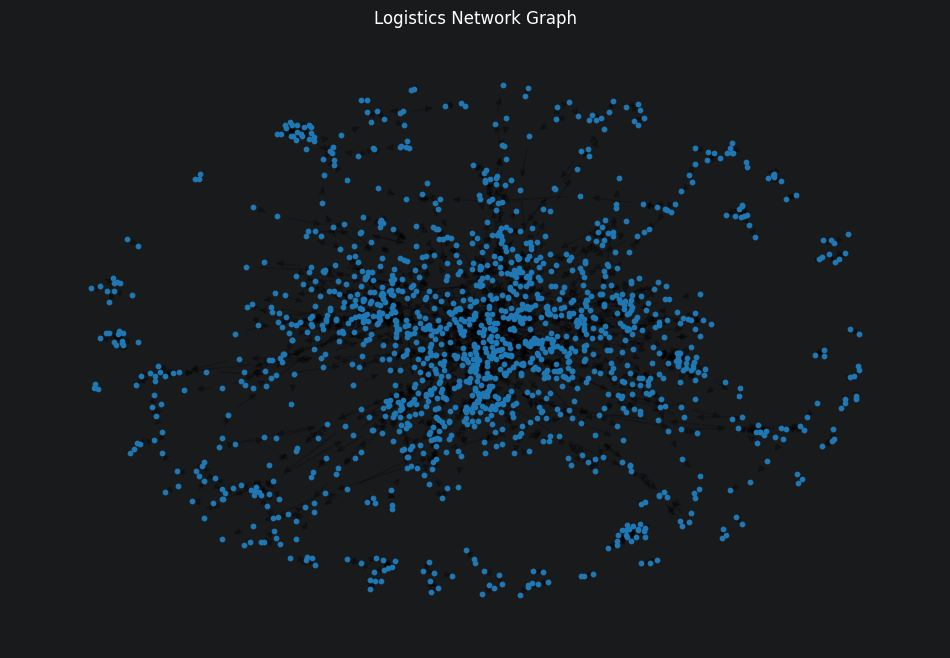

In [15]:
plt.figure(figsize=(12, 8))

pos = nx.spring_layout(G, seed=42)

nx.draw_networkx_nodes(
    G,
    pos,
    node_size=10
)

nx.draw_networkx_edges(
    G,
    pos,
    alpha=0.2
)

plt.title("Logistics Network Graph")

plt.axis("off")

plt.show()

## Top Hub Subgraph Visualization

Visualizing only the most connected hubs
for better interpretability.

In [16]:
top_nodes = top_hubs["hub"].tolist()

subgraph = G.subgraph(top_nodes)

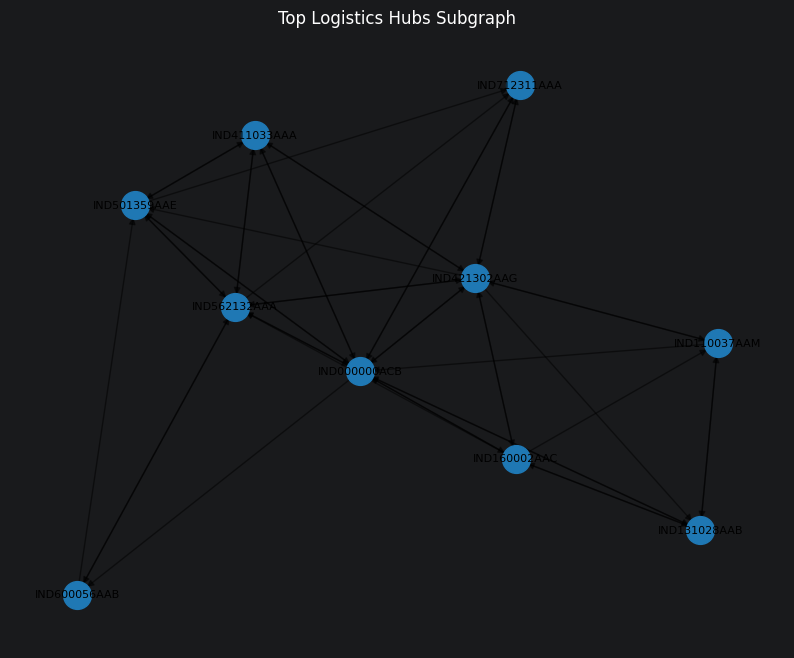

In [17]:
plt.figure(figsize=(10, 8))

sub_pos = nx.spring_layout(subgraph, seed=42)

nx.draw_networkx_nodes(
    subgraph,
    sub_pos,
    node_size=400
)

nx.draw_networkx_edges(
    subgraph,
    sub_pos,
    alpha=0.5
)

nx.draw_networkx_labels(
    subgraph,
    sub_pos,
    font_size=8
)

plt.title("Top Logistics Hubs Subgraph")

plt.axis("off")

plt.show()

## Final Observations

- The logistics network contains a dense core of highly connected hubs.
- Certain hubs play a critical role in maintaining shipment flow.
- Centrality analysis helps identify operational bottlenecks.
- Graph-based analysis provides additional network intelligence beyond traditional ML features.